<a href="https://colab.research.google.com/github/genaiconference/When-Agents-Meet-Living-Graphs/blob/main/03_retrieve_data_from_knowledge_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Retrieve Data from Knoweldge Graph

This notebook demonstrates a Retrieval-Augmented Generation (RAG) pipeline built using the Neo4j GraphRAG module. The workflow involves:

1.  **Load Neoj Graph**: Loading existing Neo4j movie graph.
2.  **Indexing**: Creating vector and full-text indexes on the graph data for efficient retrieval.
3.  **Retrieval**: Utilizing various retriever types (Vector, Vector Cypher, Hybrid, Hybrid Cypher, Text2Cypher) to fetch relevant information from the knowledge graph based on a user query.
4.  **Generation**: Using a Large Language Model (LLM) to generate an answer based on the retrieved context.

## Key Features Covered

-   **Graph Indexing**: Creation of vector and full-text indexes within Neo4j.
-   **Advanced Retrieval Strategies**: Implementation and demonstration of various retrieval mechanisms:
    -   Vector search for semantic relevance.
    -   Full-text search for lexical relevance.
    -   Cypher queries for complex graph traversal.
    -   Hybrid approaches combining vector, full-text, and Cypher.
    -   Text2Cypher for natural language to graph query translation.
-   **GraphRAG Pipeline**: Setting up and running a complete RAG pipeline to answer questions using retrieved graph context.

## Architecture Components

-   **Neo4j Graph Database**: Stores the knowledge graph data.
-   **Neo4j GraphRAG Module**: A Python library that facilitates building RAG applications with Neo4j.
    -   **LLM (OpenAILLM)**: Used for text generation (e.g., GPT-5-mini).
    -   **Embeddings (OpenAIEmbeddings)**: Used to create vector representations of text (e.g., text-embedding-3-small).
    -   **Indexes**:
        -   **Vector Index**: For semantic similarity search on node embeddings.
        -   **Full-text Index**: For lexical similarity search on node properties.
    -   **Retrievers**:
        -   `VectorRetriever`: Performs ANN vector search.
        -   `VectorCypherRetriever`: Combines vector search with Cypher queries for graph traversal.
        -   `HybridRetriever`: Combines vector and full-text search.
        -   `HybridCypherRetriever`: Combines vector and full-text search with Cypher queries.
        -   `Text2CypherRetriever`: Converts natural language to Cypher queries.
-   **Langfuse Handler (Optional)**: For tracing and observability of LLM interactions.

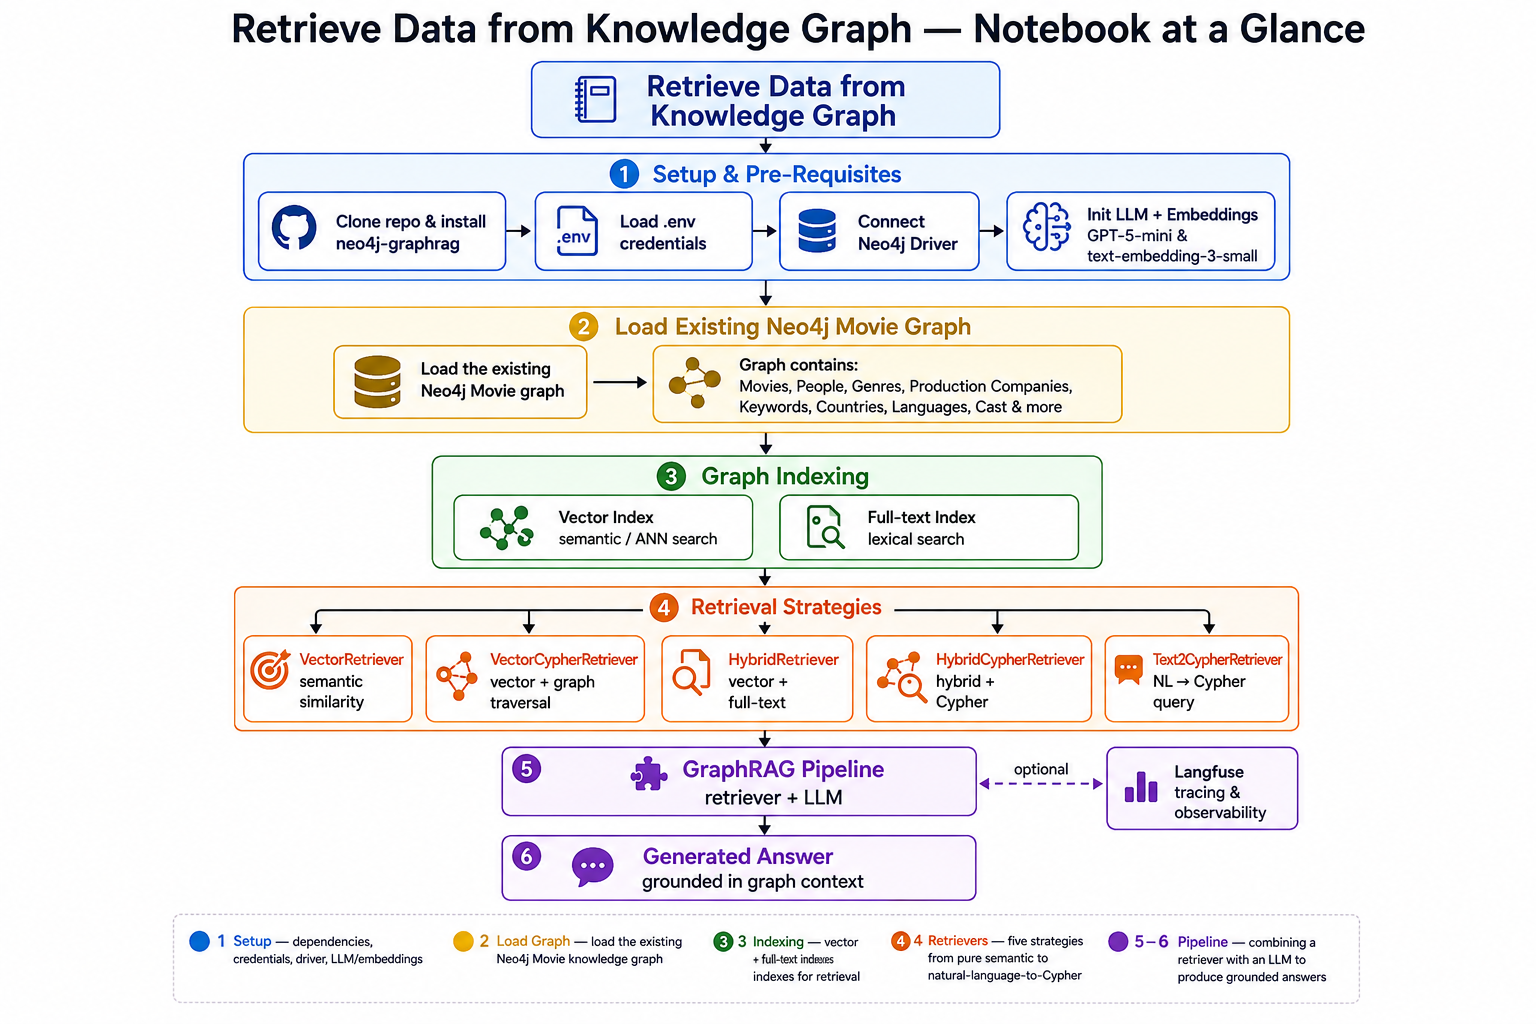

## Tech stack

-   **Neo4j Graph Database**: For storing and querying graph data.
-   **Neo4j GraphRAG Module**: Python library for building RAG applications with Neo4j.
-   **OpenAI**: For Large Language Models (LLMs) like GPT-5-mini and embedding models like text-embedding-3-small.
-   **Python**: The primary programming language used for the notebook.
-   **LangChain**: (Implicitly supported by `neo4j-graphrag` for LLM integrations).
-   **Langfuse**: (Optional) For LLM observability and tracing.

# 1. Setup & Pre-Requisites

In [1]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 312 (delta 72), reused 57 (delta 55), pack-reused 224 (from 2)
Receiving objects: 100% (312/312), 8.84 MiB | 18.33 MiB/s, done.
Resolving deltas: 100% (164/164), done.


Upload your '.env' file inside the 'Agentic_KAG_Workshop_DHS_2026' folder in the Files section
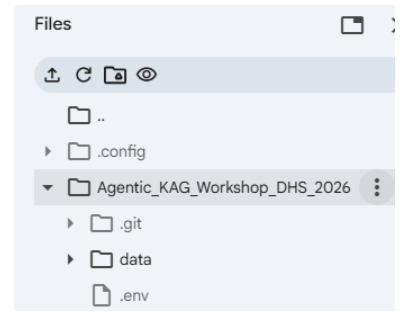

## Install Required Packages

In [1]:
!pip install -r /content/Agentic_KAG_Workshop_DHS_2026/requirements.txt --quiet

## Credentials & Drivers
The Neo4j driver allows you to connect and perform read and write transactions with the database.

In [2]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://44.204.116.51
OPENAI key set: True


In [11]:
import logging

# Suppress Neo4j server notification warnings
logging.getLogger("neo4j.notifications").setLevel(logging.ERROR)


## Initialize OpenAI LLM and Embeddings via neo4j-graphrag
We will use OpenAI **GPT-5-mini**. The GraphRAG Python package supports any LLM model, including models from OpenAI, Google VertexAI, Anthropic, Cohere, Azure OpenAI, local Ollama models, and any chat model that works with LangChain. You can also implement a custom interface for any other LLM.

Likewise, we will use OpenAI’s **text-embedding-3-small** for the embedding model, but you can use other embedders from different providers.

In [3]:
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings

llm = OpenAILLM(
    model_name="gpt-5-mini",
)

embedder = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [4]:
# Test llm call
llm.invoke("why is sky blue?")

LLMResponse(content='Sunlight is made of all visible colors (different wavelengths). As it passes through the atmosphere, gas molecules and very small particles scatter the light in all directions. The amount of scattering grows rapidly for shorter wavelengths — roughly with 1/(wavelength^4) — so blue light (shorter wavelength) is scattered much more than red light. That scattered blue light from all directions is what you see when you look at the sky.\n\nWhy not violet, which is even shorter? Three reasons: the Sun emits less violet than blue, our eyes are less sensitive to violet, and some violet is absorbed higher up. The net effect is that the sky appears blue rather than violet.\n\nRelated points:\n- At sunrise and sunset sunlight travels through a much longer path in the atmosphere, so most of the blue has been scattered away and the remaining direct light is red/orange.\n- Clouds look white because the water droplets are large enough to scatter all visible wavelengths about equa

## Initialize Langfuse Handler for Tracing

In [5]:
from langfuse.langchain import CallbackHandler
from langfuse import get_client

os.environ["LANGFUSE_PUBLIC_KEY"] = os.getenv("LANGFUSE_PUBLIC_KEY")
os.environ["LANGFUSE_SECRET_KEY"] = os.getenv("LANGFUSE_SECRET_KEY")
os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"

langfuse = get_client()

# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")

langfuse_handler = CallbackHandler()

Langfuse client is authenticated and ready!


# 2. Connect to the existing Neo4j movie graph

In [6]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
driver.verify_connectivity()
print('Connected to Neo4j ✔')

Connected to Neo4j ✔


# 3. Create a Vector & Fulltext Index




**What is an index?**

Think of an index like the index at the back of a book.

*Without an index:*

```
Search request
      ↓
Check every node in the graph
      ↓
Find matching nodes
```


*With an index:*

```
Search request
      ↓
Look inside the index
      ↓
Jump directly to matching nodes
```

Indexes can therefore make graph queries much faster. Neo4j automatically maintains an index after it has been created.

**What the output tells you**

The result commonly includes:

* name: Name of the index
* state: Whether the index is ready, usually ONLINE
* type: Index type, such as RANGE, FULLTEXT, VECTOR, TEXT, or LOOKUP
* entityType: Whether it indexes nodes or relationships
* labelsOrTypes: The node label or relationship type covered
* properties: Properties included in the index
* populationPercent: How much of the index has been built
* owningConstraint: Whether a constraint created or owns the index
indexProvider: Neo4j component managing the index

We can create a vector index in Neo4j to allow the retriever to pull back information from the nodes.

-This section's code interacts with a Neo4j graph database to create and populate indexes for efficient data retrieval.



  - **Create Vector Index:** It creates a vector index on the __Entity__ label, using the vectorProperty for embeddings and cosine similarity. This index allows for efficient similarity searches based on the vector representations of the entities.

  - **Create Full-Text Index:** It creates a full-text index on the __Entity__ label, indexing various text properties like location, theme, bio, etc. This index enables fast keyword-based searches.


  In essence, this section's code prepares the graph database for efficient searching by creating specialized indexes and ensuring that entities have unique identifiers and associated vector embeddings.

In [22]:
from neo4j_graphrag.indexes import create_vector_index, create_fulltext_index, drop_index_if_exists

## Two different retrieval indexes over the same Neo4j knowledge graph. Why Two?

The graph remains rich (Movies, Persons, Genres, Keywords, Companies), but retrieval can be tailored.

**Graph-wide indexes** retrieve any entity.

**Movie-only indexes** retrieve only Movie nodes, then Cypher expands to connected entities for multi-hop reasoning.

### 3.1 Create Graph-wide Indexes

In [25]:
for _idx in ["graph_embedding_index", "graph_text_index"]:
    drop_index_if_exists(driver, _idx)

create_vector_index(
    driver=driver,
    name="graph_embedding_index",
    label="__Entity__",
    embedding_property="embedding",
    dimensions=1536,
    similarity_fn="cosine",
)

create_fulltext_index(
    driver=driver,
    name="graph_text_index",
    label="__Entity__",
    node_properties=["name", "description"],
)

### 3.2 Create Movie-Only Indexes

In [26]:
for _idx in ["movie_embedding_index", "movie_text_index"]:
    drop_index_if_exists(driver, _idx)

create_vector_index(
    driver=driver,
    name="movie_embedding_index",
    label="Movie",
    embedding_property="embedding",
    dimensions=1536,
    similarity_fn="cosine",
)

create_fulltext_index(
    driver=driver,
    name="movie_text_index",
    label="Movie",
    node_properties=["title", "overview", "tagline"],
)

### Design Pattern & When to Use Which

```text
User Query
    │
    ▼
Movie Hybrid Retrieval
    │
Relevant Movie Nodes
    │
    ▼
Cypher Expansion
    ├── Genres
    ├── Cast
    ├── Directors
    ├── Keywords
    └── Companies
    │
    ▼
LLM Response
```

The graph is rich, but retrieval is focused. This separation improves retrieval quality while preserving multi-hop reasoning.

| Approach | Precision | Reasoning depth | Latency | Best for |
|---|---|---|---|---|
| **Graph-wide hybrid** | Lower (any entity type) | Shallow | Fast | Broad "what do we know about X" lookups |
| **Movie-only hybrid** | High (movies only) | Shallow | Fast | Finding the right movie fast |
| **Movie + Cypher expansion** | High | Deep (multi-hop) | Moderate | Grounded recommendations & explanations |

**Rule of thumb:** retrieve narrowly, expand deliberately. Keep the retrieval index focused
(Movies) and let Cypher pull in the surrounding graph context on demand.


Let's goto Neo4j browser to check if our indexes have got created using the below cypher


```
SHOW INDEXES
WHERE type IN ['FULLTEXT', 'VECTOR']
```



`SHOW INDEXES` is a Neo4j Cypher command that lists all indexes available in the currently selected database. It only displays information and does not create, delete, or modify anything

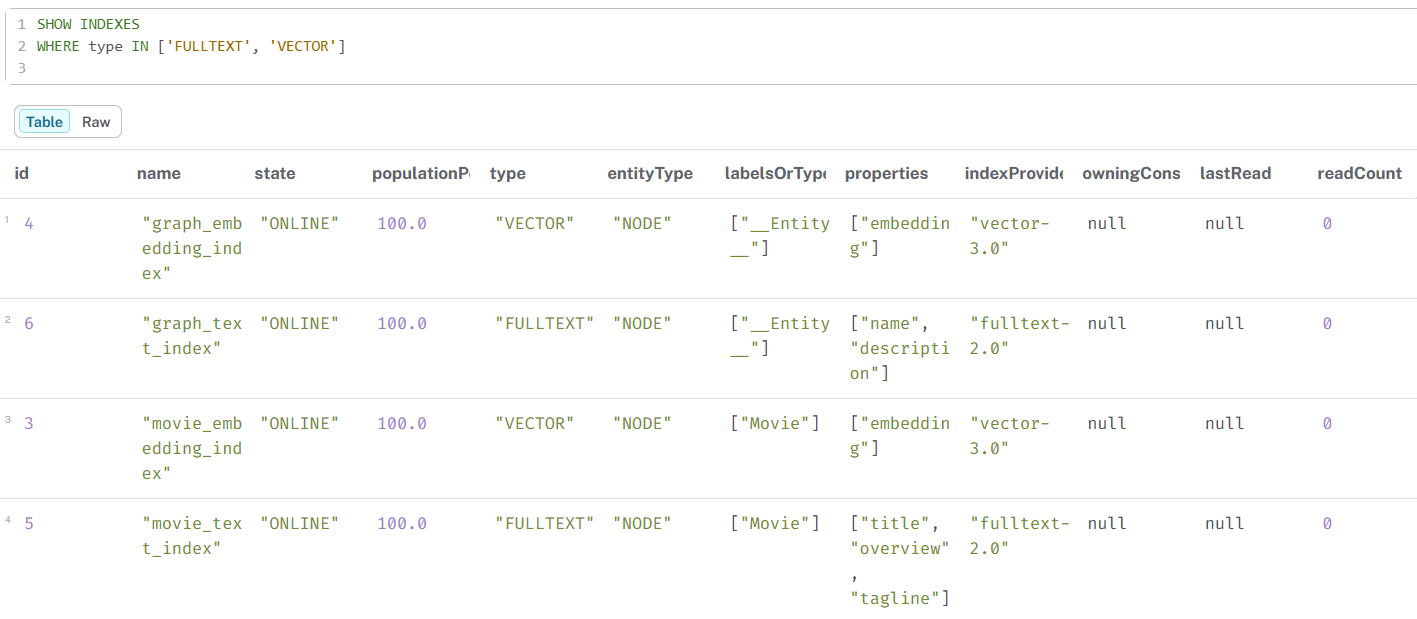

# 4. Retrieve Data from Knowledge Graph

### Neo4J GraphRAG
The GraphRAG Python package provides multiple classes for retrieving data from your knowledge graph, including:

1. **Vector Retriever:** performs similarity searches using vector embeddings

2. **Vector Cypher Retriever:** combines vector search with retrieval queries in Cypher, Neo4j’s Graph Query language, to traverse the graph and incorporate additional nodes and relationships.

3. **Hybrid Retriever:** Combines vector and full-text search.

4. **Hybrid Cypher Retriever:** Combines vector and full-text search with Cypher retrieval queries for additional graph traversal.

5. **Text2Cypher:** converts natural language queries into Cypher queries to run against Neo4j.

#### Retriever Gallery

`neo4j-graphrag` ships several retriever types. Below is a runnable example of each,
using the indexes and `driver`/`embedder`/`llm` created earlier.

| Retriever | How it finds nodes | Adds Cypher expansion? | Typical use |
|---|---|---|---|
| `VectorRetriever` | Vector similarity | No | Pure semantic search |
| `VectorCypherRetriever` | Vector similarity | Yes | Semantic + multi-hop context |
| `HybridRetriever` | Vector + full-text | No | Robust semantic + keyword |
| `HybridCypherRetriever` | Vector + full-text | Yes | Hybrid + multi-hop context |
| `Text2CypherRetriever` | LLM-generated Cypher | N/A (query is Cypher) | Structured / aggregate questions |

### 🎨 A reusable helper to pretty-print retriever results

Each retriever returns results in a slightly different shape:

| Retriever | Result attribute | Item shape |
|-----------|------------------|------------|
| `VectorRetriever` / `VectorCypherRetriever` (`get_search_results`) | `.records` | `neo4j.Record` |
| `HybridRetriever` / `HybridCypherRetriever` / `Text2CypherRetriever` (`search`) | `.items` | `RetrieverResultItem` (`.content`, `.metadata`) |

Instead of writing a custom `for ... print()` loop each time, the helper below normalizes
**any** of these into a tidy **pandas DataFrame** (with the similarity `score` pulled out when
available). It falls back gracefully if the content isn't a dict-like string.


In [27]:
from helper_utils import pretty_retriever_results

## 4.1. Vector Retriever - pure semantic search

The Vector Retriever uses Approximate Nearest Neighbor (ANN) vector search to retrieve data from your knowledge graph.

**Finds nodes by embedding similarity only. Fastest, no keyword matching, no graph expansion.**

You can then instantiate the vector retriever using the code below:

In [31]:
from neo4j_graphrag.retrievers import VectorRetriever

vector_retriever = VectorRetriever(
   driver,
   index_name="movie_embedding_index",
   embedder=embedder,
   return_properties=["title", "overview"],
)

Now, let’s run this retriever with a simple prompt. The retriever can pull back text chunks and vector similarity scores, providing some useful context for answering questions in RAG.

In [35]:
vector_res = vector_retriever.get_search_results(query_text="A heartwarming animated film about family and growing up", top_k=5)

# Pretty-print the records as a tidy DataFrame
pretty_retriever_results(vector_res, title="Vector Retriever")

#### Vector Retriever  &nbsp;·&nbsp; _5 result(s)_

,title,overview,nodeLabels,elementId,id,score
0,Awe!,‘Awe’ charts the journey of a motley of charac...,"[__KGBuilder__, Movie, __Entity__]",4:44917bfd-059f-4093-aa7a-63f3577a09b1:7901,4:44917bfd-059f-4093-aa7a-63f3577a09b1:7901,0.6983
1,Shyam Singha Roy,A young filmmaker is in a soup right when he’s...,"[__KGBuilder__, Movie, __Entity__]",4:44917bfd-059f-4093-aa7a-63f3577a09b1:10188,4:44917bfd-059f-4093-aa7a-63f3577a09b1:10188,0.6942
2,Gully Boy,A coming-of-age story based on the lives of st...,"[__KGBuilder__, Movie, __Entity__]",4:44917bfd-059f-4093-aa7a-63f3577a09b1:1227,4:44917bfd-059f-4093-aa7a-63f3577a09b1:1227,0.6852
3,The Sky Is Pink,The 25-year-old love story of a couple is told...,"[__KGBuilder__, Movie, __Entity__]",4:44917bfd-059f-4093-aa7a-63f3577a09b1:3874,4:44917bfd-059f-4093-aa7a-63f3577a09b1:3874,0.6834
4,Kapoor & Sons,"Returning home to visit their ill grandfather,...","[__KGBuilder__, Movie, __Entity__]",4:44917bfd-059f-4093-aa7a-63f3577a09b1:1300,4:44917bfd-059f-4093-aa7a-63f3577a09b1:1300,0.6819


## 2. Vector Cypher Retriever

Another useful retriever to explore is the Vector Cypher Retriever, which lets you use Cypher, Neo4j’s graph query language, to incorporate graph traversal logic after retrieving an initial set of nodes with vector search. Below we create a retriever to obtain relevant nodes via vector search

In [46]:
###------------------------------------------------------------------------------------#
#This is the core pattern: retrieve **focused** Movie nodes with the movie vector index,
# then expand via Cypher to connected Genres, Cast, Directors, Keywords, and Companies —
# giving the LLM rich multi-hop context without polluting the retrieval step.
#---------------------------------------------------------------------------------------#

EXPANSION_QUERY = """
WITH node AS movie, score
OPTIONAL MATCH (movie)-[:HAS_GENRE]->(g:Genre)
OPTIONAL MATCH (movie)<-[:CAST_IN]-(actor:Person)
OPTIONAL MATCH (movie)-[:TAGGED_WITH]->(k:Keyword)
OPTIONAL MATCH (movie)-[:PRODUCED_IN]->(c:Country)
RETURN
  movie.title AS title,
  coalesce(movie.overview, "") AS overview,
  score,
  collect(DISTINCT g.name)        AS genres,
  collect(DISTINCT actor.name)    AS cast,
  collect(DISTINCT k.name)        AS keywords,
  collect(DISTINCT c.name)        AS countries
ORDER BY score DESC"""

In [48]:
from neo4j_graphrag.retrievers import VectorCypherRetriever

vc_retriever = VectorCypherRetriever(
   driver,
   index_name="movie_embedding_index",
   embedder=embedder,
   retrieval_query = EXPANSION_QUERY,
)

Submitting the same prompt, here’s the context we get back:

In [49]:
vc_res = vc_retriever.get_search_results(query_text="A dark psychological thriller with an unreliable narrator?", top_k=3)

# Pretty-print the records as a tidy DataFrame
pretty_retriever_results(vc_res, title="Vector Cypher Retriever")


#### Vector Cypher Retriever  &nbsp;·&nbsp; _3 result(s)_

,title,overview,genres,cast,keywords,countries,score
0,Irul,"A dark rainy night, an empty house, a stranded...","[Thriller, Mystery]","[Fahadh Faasil, Soubin Shahir, Darshana Rajend...",[],[India],0.7348
1,Evil Eye,A seemingly perfect romance turns dark when a ...,"[Thriller, Mystery, Horror]","[Sarita Choudhury, Sunita Mani, Bernard White,...","[reincarnation, south asian]",[United States of America],0.7255
2,Anjaam Pathiraa,A psychologist with a keen interest in crimino...,"[Thriller, Crime, Mystery]","[Sreenath Bhasi, Kunchacko Boban, Unnimaya Pra...",[],[India],0.7180


### Limitations of Vector Retrieval

**Domain-specific limitations**: Vector search can struggle with domain-specific terms or jargon that are not well-represented in the embedding model’s training data.

**Not ideal for precise string matching**: It may not accurately find results when the query depends on exact matches for specific names, numbers, or dates.


## Full-Text Indexes
Fortunately, there is a solution to this issue: full-text indexes. Unlike vector indexes, which match strings based on semantic similarity, full-text indexes match pieces of text based on lexical similarity, meaning they compare the exact wording or text structure.

## 3. Hybrid Retriever




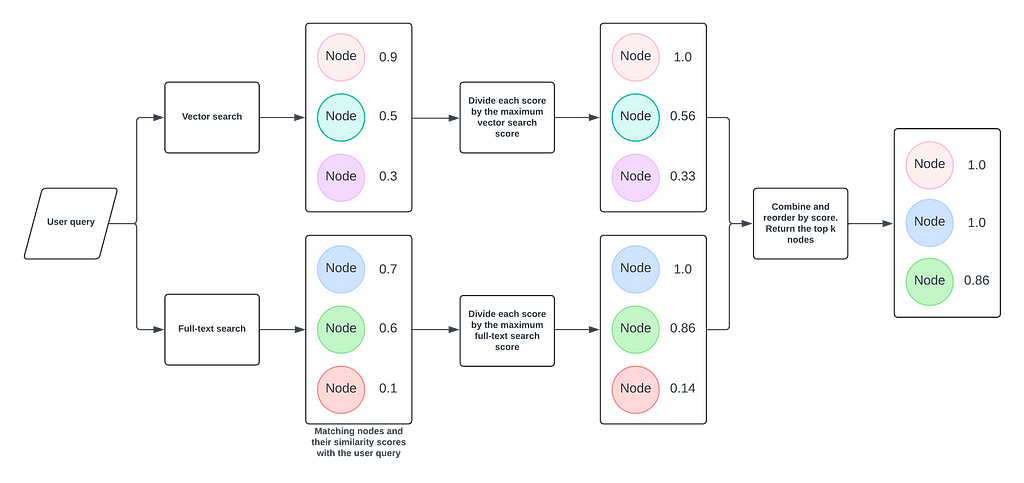

We use full-text indexes for our GraphRAG applications by using the **HybridRetriever class** from the Neo4j GraphRAG Python library. This retriever leverages both a **vector index** and a **full-text index** in a process known as **hybrid search.** It uses the user query to search both indexes, retrieving nodes and their corresponding scores. After normalizing the scores from each set of results, it merges them, ranks the combined results by score, and returns the top matches.

In [43]:
from neo4j_graphrag.retrievers import HybridRetriever

hybrid_retriever = HybridRetriever(
    driver=driver,
    vector_index_name="movie_embedding_index",
    fulltext_index_name="movie_text_index",
    embedder=embedder,
    return_properties=[
        "title",
        "overview",
        "vote_average",
        "release_date"
    ]
)

query_text = "An epic space sci-fi featuring a character named Bahubali"
retriever_result = hybrid_retriever.search(
    query_text=query_text,
    top_k=3
)

# Pretty-print the results as a tidy DataFrame
pretty_retriever_results(retriever_result, title="Hybrid Retriever Results")


#### Hybrid Retriever Results  &nbsp;·&nbsp; _3 result(s)_

,overview,title,release_date,vote_average,score
0,Dharma is stuck in a rut with his negative and...,777 Charlie,2022-06-10,7.633,1.0000
1,"When Mahendra, the son of Bāhubali, learns abo...",Bāhubali 2: The Conclusion,2017-04-27,7.394,1.0000
2,"The story of a great Indian rocket scientist, ...",Rocketry: The Nambi Effect,2022-07-01,7.5,0.9753


## 4. Hybrid Cypher Retriever
The HybridCypherRetriever enhances the hybrid search process by adding a graph traversal step. It begins by identifying an initial set of nodes through a combined search over vector and full-text indexes, then uses a specified Cypher query to retrieve additional information from the graph for each of these nodes.


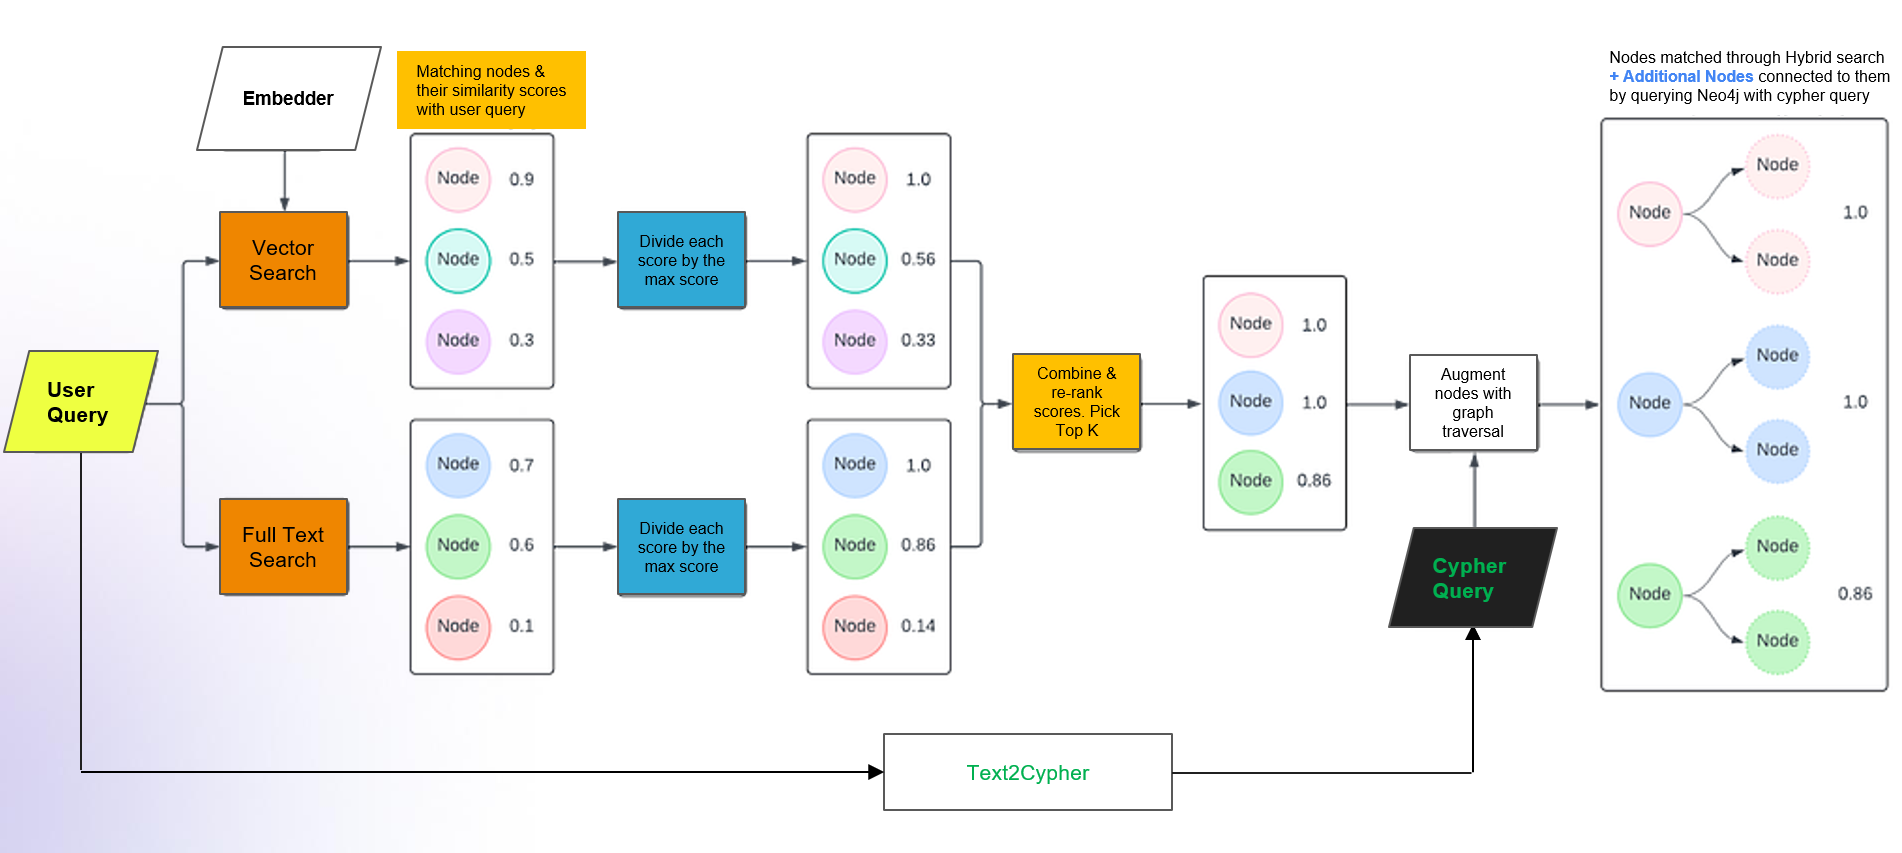

To make use of this retriever, we first need to write a Cypher query to specify exactly what additional information to fetch along with each of the nodes retrieved through hybrid search. Given we are looking to answer questions about actors in movies, we can use the following query:

**A dark superhero film with a chaotic joker villain**

This example performs a hybrid search to find the target movie node, then traverses the :CAST_IN relationships backwards to find all actors cast in that movie, along with their character roles.

We then pass this query to the HybridCypherRetriever with the names of the vector and full-text indexes we want to search.

In [50]:
from neo4j_graphrag.retrievers import HybridCypherRetriever

hc_retriever = HybridCypherRetriever(
    driver=driver,
    vector_index_name="movie_embedding_index",
    fulltext_index_name="movie_text_index",
    retrieval_query=EXPANSION_QUERY,
    embedder=embedder,
)
query_text = "A dark superhero film with a chaotic joker villain"
retriever_result = hc_retriever.search(query_text=query_text, top_k=5)

# Pretty-print the results as a tidy DataFrame
pretty_retriever_results(retriever_result, title="Hybrid Cypher Retriever — A dark superhero film with a chaotic joker villain")


#### Hybrid Cypher Retriever — A dark superhero film with a chaotic joker villain  &nbsp;·&nbsp; _5 result(s)_

,content
0,<Record title='A Flying Jatt' overview='Jatt i...
1,<Record title='The Field Guide to Evil' overvi...
2,<Record title='Saaho' overview='A battle for p...
3,"<Record title='Thunivu' overview=""A gang goes ..."
4,<Record title='Jagame Thandhiram' overview='Wh...


## 5. Text2Cypher Retriever

**Recap - What is Cypher?**
 Cypher is the primary query language used with graph databases, and an example can be seen below.



```
MATCH (p:Person)-[l:LIVES_AT]->(a:Address)
WHERE p.name = "Bob" and l.since >= date('2025-01-01')
RETURN a.address as address
```



Text2Cypher retriever first asks an LLM to generate a Cypher query to fetch the exact information required to answer the question from the database. Then this query is executed and the resulting records are added to the context for the LLM to write the answer to the initial user question.

The workflow for generating Cypher queries from natural language questions can
be broken down into the following steps:
- Retrieve the question from the user.
- Retrieve the schema of the knowledge graph.
- Define other useful information like terminology mappings, format instructions, and few-shot examples.
- Generate the prompt for the LLM.
- Pass the prompt to the LLM to generate the Cypher query.


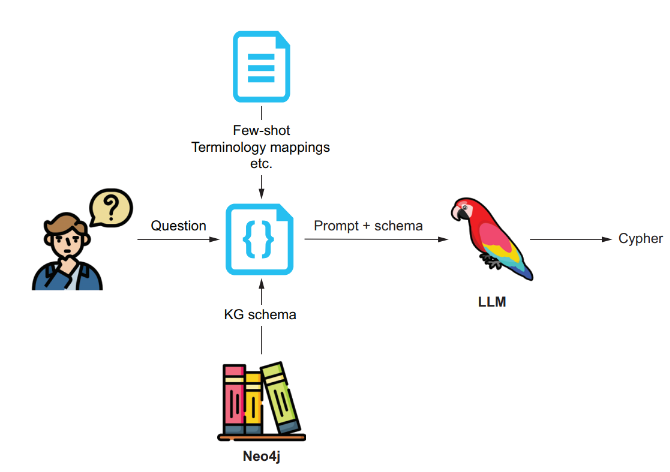

In [53]:
from neo4j_graphrag.retrievers import Text2CypherRetriever
from neo4j_graphrag.schema import get_schema

import prompts
from examples import examples

schema = get_schema(driver)

t2c_retriever = Text2CypherRetriever(
    driver=driver,
    llm=llm,
    neo4j_schema=schema,
    custom_prompt=prompts.custom_text2cypher_prompt,
    examples=examples,
)


In [54]:
# Define a sample query in natural language
query_text1 = "List the top 10 highest-rated Hindi movies"

# Convert the natural language query to Cypher, execute it, and pretty-print
response = t2c_retriever.search(query_text=query_text1)

# The helper also renders the generated Cypher (from response.metadata['cypher'])
pretty_retriever_results(response, title="Text2Cypher Retriever — top 10 Hindi movies")

#### Text2Cypher Retriever — top 10 Hindi movies  &nbsp;·&nbsp; _10 result(s)_

**Generated Cypher**
```cypher
MATCH (m:Movie)-[:SPOKEN_IN]->(l:Language)
WHERE toLower(l.name) CONTAINS toLower('hindi')
RETURN DISTINCT m.title, m.vote_average, m.release_date
ORDER BY m.vote_average DESC
LIMIT 10
```

,content
0,<Record m.title='Spider-Man: Across the Spider...
1,<Record m.title='Sonchiriya' m.vote_average=8....
2,<Record m.title='Lion' m.vote_average=8.083 m....
3,<Record m.title='Jersey' m.vote_average=8.0 m....
4,<Record m.title='Sanam Teri Kasam' m.vote_aver...
5,<Record m.title='Dangal' m.vote_average=7.934 ...
6,<Record m.title='Period. End of Sentence.' m.v...
7,<Record m.title='Kammatipaadam' m.vote_average...
8,<Record m.title='Drishyam 2' m.vote_average=7....
9,<Record m.title='The Farthest' m.vote_average=...


In [55]:
# Define a sample query in natural language
query_text2 = "Which 5 directors have directed the most movies"

# Convert the natural language query to Cypher, execute it, and pretty-print
response = t2c_retriever.search(query_text=query_text2)

# The helper also renders the generated Cypher (from response.metadata['cypher'])
pretty_retriever_results(response, title="Text2Cypher Retriever — Directors")

#### Text2Cypher Retriever — Directors  &nbsp;·&nbsp; _5 result(s)_

**Generated Cypher**
```cypher
MATCH (m:Movie)-[:DIRECTED_BY]->(p:Person)
RETURN p.name AS director, COUNT(DISTINCT m) AS movie_count
ORDER BY movie_count DESC
LIMIT 5
```

,content
0,<Record director='Anurag Kashyap' movie_count=6>
1,<Record director='Sujoy Ghosh' movie_count=4>
2,<Record director='Karan Johar' movie_count=4>
3,<Record director='R Balki' movie_count=4>
4,<Record director='Manish Rana' movie_count=4>


# GraphRAG Pipeline

To turn the retriever search into a full GraphRAG pipeline, we simply add the following code:

Let's continue by running the GraphRAG pipeline with each of the defined retrievers.

In [56]:
from neo4j_graphrag.generation import GraphRAG
from IPython.display import display, Markdown
import json

def query_graph(retriever, llm, query_text, retriever_config):
  """Queries the graph using a GraphRAG pipeline.

  Args:
    retriever: The retriever to use.
    llm: The language model to use.
    query_text: The query text.
    retriever_config: The retriever configuration.

  Returns:
    The response from the GraphRAG pipeline.
  """
  # Initialize the RAG pipeline
  rag = GraphRAG(retriever=retriever, llm=llm)

  # Query the graph
  response = rag.search(query_text=query_text,
                        retriever_config=retriever_config,
                        return_context=True,
                        response_fallback="I can not answer this question because I have no relevant context.",
                        # config={"callbacks": [langfuse_handler]}
                        )
  return response.answer

query_text = "List down movies similar to Interstellar?"
top_k_value = 5

# Get results from Vector Retriever using query_graph function
display(Markdown("### Vector Retriever Results (using GraphRAG)"))
response = query_graph(vector_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

# Get results from Vector Cypher Retriever using query_graph function
display(Markdown("### Vector Cypher Retriever Results (using GraphRAG)"))
response = query_graph(vc_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

# Get results from Text2Cypher Retriever using the query_graph function
display(Markdown("### Text2Cypher Retriever Results (using GraphRAG)"))
# response = query_graph(t2c_retriever, llm, query_text, {})
# display(Markdown(response))

# Get results from Hybrid Retriever using query_graph function
display(Markdown("### Hybrid Retriever Results (using GraphRAG)"))
response = query_graph(hybrid_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

# Get results from Hybrid Cypher Retriever using the query_graph function
display(Markdown("### Hybrid Cypher Retriever Results (using GraphRAG)"))
response = query_graph(hc_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

### Vector Retriever Results (using GraphRAG)

- The Wandering Earth — a large-scale, high-stakes science-fiction epic about humanity moving the planet to survive an existential threat, thematically and tonally closest to Interstellar.

### Vector Cypher Retriever Results (using GraphRAG)

The Wandering Earth — large-scale science-fiction drama about humanity saving the planet from a dying Sun (features planetary engineering, global government-scale action and strong family relationships), making it the closest match in the provided list.

### Text2Cypher Retriever Results (using GraphRAG)

### Hybrid Retriever Results (using GraphRAG)

From the provided list the closest match is:

- The Wandering Earth (2019-02-05) — vote_average 6.569  
  Reason: large-scale sci-fi about moving the Earth and an epic interstellar journey to save humanity, thematically similar to Interstellar.

The other titles (The Bubble, AK vs AK, Maayavan, Kaalakaandi) are comedy/drama or thrillers and aren't really similar. Would you like more Interstellar-like recommendations beyond this list?

### Hybrid Cypher Retriever Results (using GraphRAG)

From the provided list, these are the films most similar to Interstellar:

- The Wandering Earth — Science Fiction / Action / Drama (China)  
  Why: Global-scale sci-fi about saving humanity by moving the planet, with dying-sun/frozen-Earth stakes and family relationships — very close in scope and theme to Interstellar.

- Maayavan — Science Fiction / Action / Thriller (India)  
  Why: Has science-fiction elements (brain research) and a thriller/action approach; less cosmic in scale than Interstellar but the only other sci-fi on the list.

The other titles in the provided set (The Bubble, Kaalakaandi, AK vs AK) are not similar in genre or scale to Interstellar.